### Importing Libraries

In [1]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

GPU Usage?

In [2]:
import tensorflow as tf

if tf.config.list_physical_devices('GPU'):
    print("TensorFlow is using the GPU!")

    gpus = tf.config.list_physical_devices('GPU')
    print("Available GPUs:", gpus)

    for gpu in gpus:
        details = tf.config.experimental.get_device_details(gpu)
        print("GPU Details:", details)
else:
    print("TensorFlow is using the CPU.")

TensorFlow is using the GPU!
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU Details: {'device_name': 'NVIDIA GeForce RTX 3050 Laptop GPU', 'compute_capability': (8, 6)}


In [3]:
import os
from tensorflow.keras.models import load_model

MODEL_PATH = r"C:\CODES__SSD512\minorP_Pneumonia\Notebooks\H5\E18_ResNet50_P1I3A2M6T3.keras"

if os.path.exists(MODEL_PATH):
    model = load_model(MODEL_PATH)
    print("\nModel loaded successfully")
else:
    print("\nModel not found! Check the path.")


Model not found! Check the path.


In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Pneumonia Data___Set


In [5]:
labels = ['PNEUMONIA', 'NORMAL']
img_resize = 224

def get_data(dir):
    data = []
    
    for label in labels:
        path = os.path.join(dir, label)
        class_num = labels.index(label)

        for img in os.listdir(path):
            try:
                if img.lower().endswith(('.jpeg', '.jpg', '.png')):
                    img_path = os.path.join(path, img)

                    #grayscale
                    img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                    if img_arr is None:
                        continue

                    # Resize
                    resized_arr = cv2.resize(img_arr, (img_resize, img_resize))

                    # 3-channel
                    rgb_arr = cv2.cvtColor(resized_arr, cv2.COLOR_GRAY2RGB)

                    data.append([rgb_arr, class_num])

            except Exception as e:
                print(f"Error loading image {img}: {e}")

    return np.array(data, dtype='object')

In [6]:
train = get_data(r"C:\CODES__SSD512\minorP_Pneumonia\ChestXRay2017\chest_xray\train")
val   = get_data(r"C:\CODES__SSD512\minorP_Pneumonia\ChestXRay2017\chest_xray\val")
test  = get_data(r"C:\CODES__SSD512\minorP_Pneumonia\ChestXRay2017\chest_xray\test")

In [7]:
def count_images(dataset, name):

    pneumonia = 0
    normal = 0

    for i in dataset:
        if i[1] == 0:
            pneumonia += 1
        else:
            normal += 1

    total = pneumonia + normal

    print(f"\n{name} DATASET:")
    print("Total images:", total)
    print("PNEUMONIA images:", pneumonia)
    print("NORMAL images:", normal)


count_images(train, "TRAIN")
count_images(val, "VALIDATION")
count_images(test, "TEST")


TRAIN DATASET:
Total images: 5170
PNEUMONIA images: 3852
NORMAL images: 1318

VALIDATION DATASET:
Total images: 62
PNEUMONIA images: 31
NORMAL images: 31

TEST DATASET:
Total images: 624
PNEUMONIA images: 390
NORMAL images: 234


## Data Visualization && Preprocessing

<Axes: xlabel='count'>

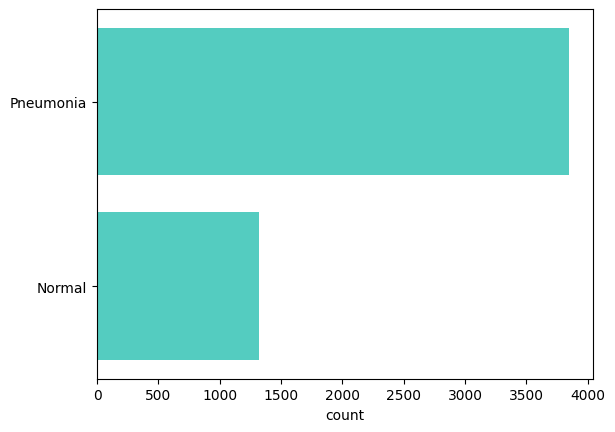

In [8]:
l = []
for i in train:
    if (i[1] == 0):
        l.append('Pneumonia')
    else:
        l.append('Normal')

sns.countplot(y=l, color='#40E0D0')

Text(0.5, 1.0, 'NORMAL')

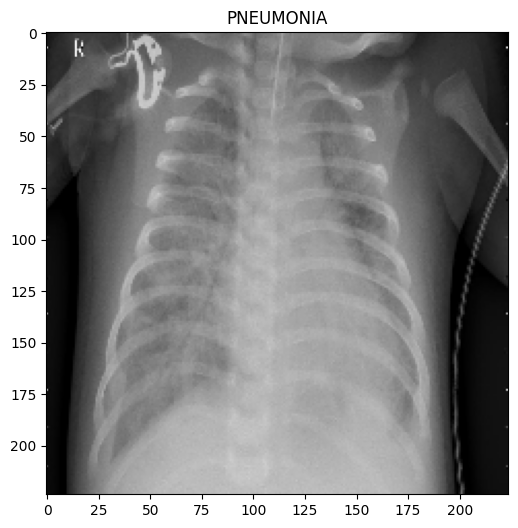

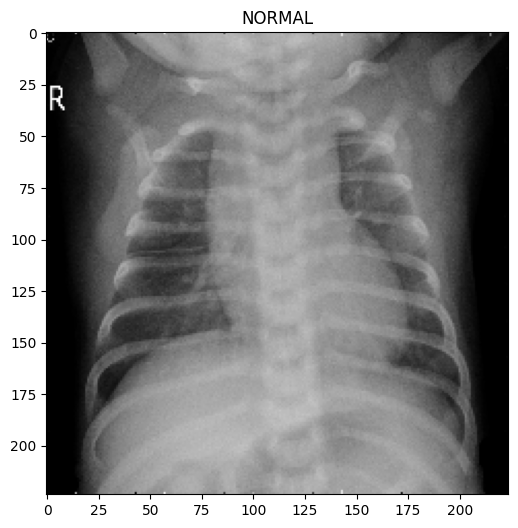

In [9]:
plt.figure(figsize=(6,6))
plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize=(6,6))
plt.imshow(train[-11][0], cmap='gray')
plt.title(labels[train[-11][1]])

In [10]:
x_train = []
y_train = []
for feat, label in train:
    x_train.append(feat)
    y_train.append(label)


x_val = []
y_val = []
for feat,label in val:
    x_val.append(feat)
    y_val.append(label)


x_test = []
y_test = []
for feat, label in test:
    x_test.append(feat)
    y_test.append(label)


In [11]:
# print(type(x_train))
# print(type(x_train[0]))
# print("First train image shape:", np.array(x_train[0]).shape)
# print("First val image shape:", np.array(x_val[0]).shape)
# print("First test image shape:", np.array(x_test[0]).shape)

## Normalizing       data ........

In [12]:
#Normalizing.... data
# for reducing computation....
x_train = np.array(x_train, dtype='float32') / 255.0
x_val   = np.array(x_val, dtype='float32') / 255.0
x_test  = np.array(x_test, dtype='float32') / 255.0

# suitable for CNN

In [13]:
x_train = np.array(x_train)
y_train = np.array(y_train)

x_val = np.array(x_val)
y_val = np.array(y_val)

x_test = np.array(x_test)
y_test = np.array(y_test)

print("x_train shape:", x_train.shape)
print("x_val shape:", x_val.shape)
print("x_test shape:", x_test.shape)

x_train shape: (5170, 224, 224, 3)
x_val shape: (62, 224, 224, 3)
x_test shape: (624, 224, 224, 3)


# data augmentation

In [14]:
data__gen = ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True
)

data__gen.fit(x_train)

## Train........

In [15]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam


# Base Model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


# Freeze Base Model
base_model.trainable = False


# Input Layer
inputs = Input(
    shape=(224, 224, 3)
)


# Feature Extraction from ResNet50
x = base_model(
    inputs,
    training=False
)


# Global Average Pooling Layer
x = GlobalAveragePooling2D()(x)


# Dense Layer
x = Dense(
    128,
    activation='relu'
)(x)


# Dropout Layer
x = Dropout(
    0.30
)(x)


# Output Layer
outputs = Dense(
    1,
    activation='sigmoid'
)(x)


# Final Model
model = Model(
    inputs,
    outputs
)


# Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# Summary
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               262272    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                             

In [16]:
# learning_rate_reduction = ReduceLROnPlateau(
#     monitor='val_accuracy',
#     patience=2,
#     verbose=1,
#     factor=0.3,
#     min_lr=0.000001
# )

# T3 = Fine tuning head

In [17]:
# checkpoint = ModelCheckpoint(
#     MODEL_PATH,
#     monitor='val_accuracy',
#     save_best_only=True,
#     verbose=1
# )


# No checkpoint

In [18]:
# from sklearn.utils.class_weight import compute_class_weight

# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train),
#     y=y_train
# )

# class_weights = dict(enumerate(class_weights))
# print(class_weights)

# T3 = Fine-tune head
# No class weights used

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    data__gen.flow(x_train, y_train, batch_size=16),
    validation_data=(x_val, y_val),
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
324/324 [==============================] - 157s 385ms/step - loss: 0.5520 - accuracy: 0.7431 - val_loss: 0.7546 - val_accuracy: 0.5000
Epoch 2/30
324/324 [==============================] - 124s 381ms/step - loss: 0.4765 - accuracy: 0.7605 - val_loss: 0.5044 - val_accuracy: 0.7581
Epoch 3/30
324/324 [==============================] - 124s 383ms/step - loss: 0.4172 - accuracy: 0.7917 - val_loss: 0.5029 - val_accuracy: 0.6935
Epoch 4/30
324/324 [==============================] - 124s 381ms/step - loss: 0.3943 - accuracy: 0.8039 - val_loss: 0.4286 - val_accuracy: 0.7903
Epoch 5/30
324/324 [==============================] - 63s 192ms/step - loss: 0.3849 - accuracy: 0.8106 - val_loss: 0.3991 - val_accuracy: 0.7742
Epoch 6/30
324/324 [==============================] - 103s 316ms/step - loss: 0.3636 - accuracy: 0.8246 - val_loss: 0.4018 - val_accuracy: 0.8226
Epoch 7/30
324/324 [==============================] - 117s 362ms/step - loss: 0.3587 - accuracy: 0.8280 - val_loss: 0.4249 - 

In [20]:
model.save(MODEL_PATH)
print("Model saved successfully.....")

Model saved successfully.....


In [21]:
model.evaluate(x_test,y_test)

20/20 [==============================] - 3s 129ms/step - loss: 0.4044 - accuracy: 0.8141


[0.40440255403518677, 0.8141025900840759]

In [22]:

print(f"Loss of the model is {model.evaluate(x_test,y_test)[0]}")
print(f"Accuracy of the model is {model.evaluate(x_test,y_test)[1]*100} %")

20/20 [==============================] - 3s 131ms/step - loss: 0.4044 - accuracy: 0.8141
Loss of the model is 0.40440255403518677
20/20 [==============================] - 3s 143ms/step - loss: 0.4044 - accuracy: 0.8141
Accuracy of the model is 81.41025900840759 %


# Analyse Model Performance

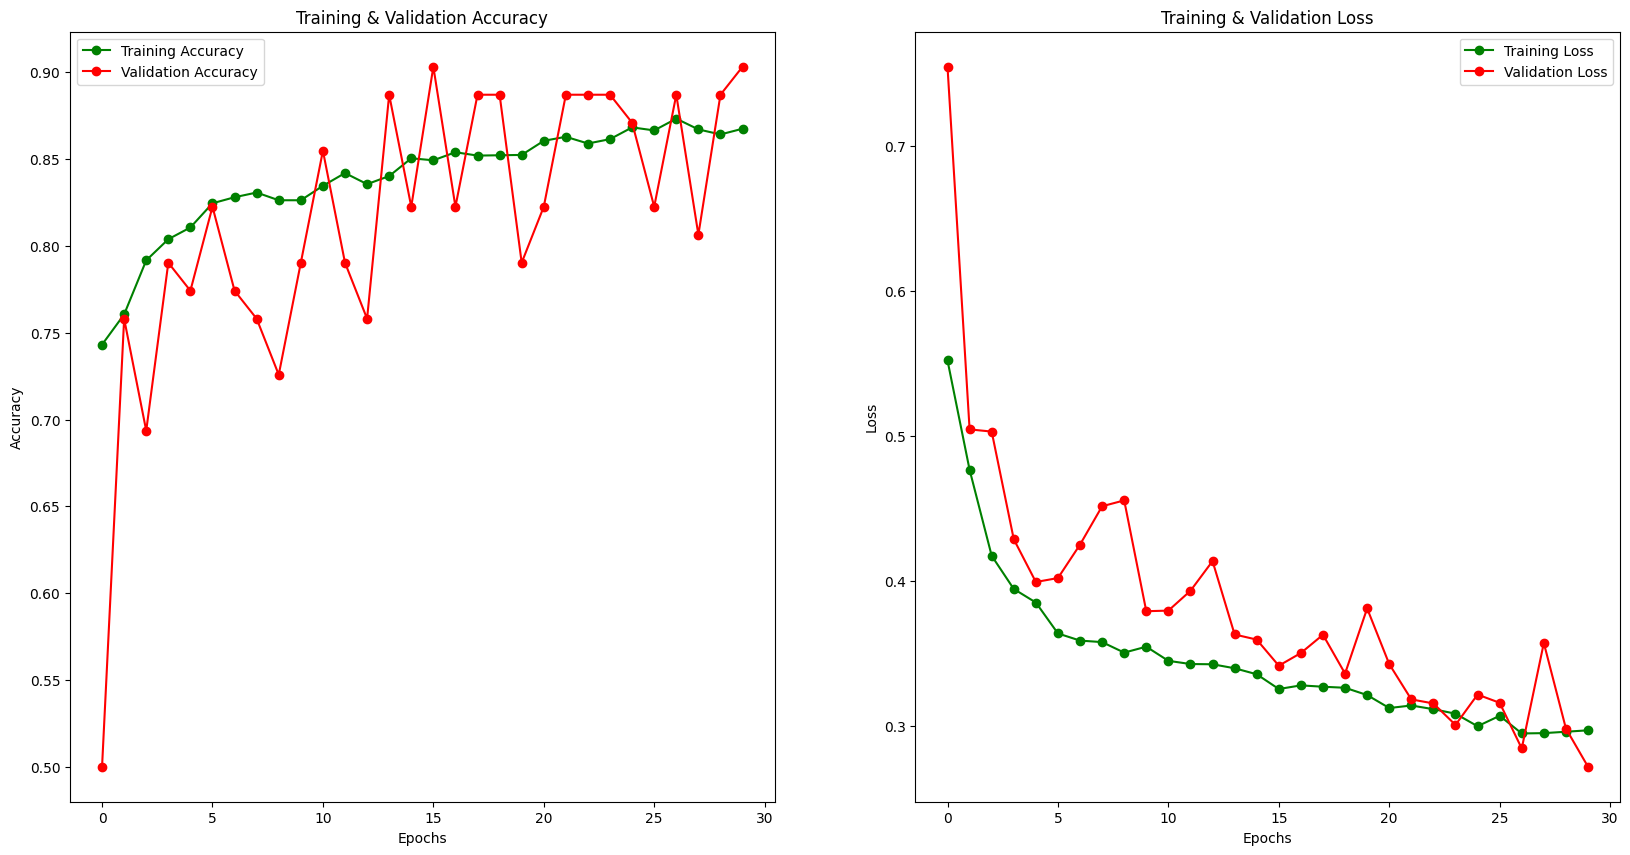

In [23]:
epochs = range(len(history.history['accuracy']))
fig, ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

fig.set_size_inches(20,10)

ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')


ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
ax[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
ax[1].set_title('Training & Validation Loss')
ax[1].legend()
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
plt.show()

In [24]:
predictions = (model.predict(x_test) > 0.5).astype('int32')
predictions = predictions.reshape(1,-1)[0]
predictions[:15]

20/20 [==============================] - 7s 124ms/step


array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [25]:
print(classification_report(y_test, predictions, target_names=['Pneumonia (Class 0)', 'Normal (Class 1)']))


                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.83      0.88      0.86       390
   Normal (Class 1)       0.78      0.70      0.74       234

           accuracy                           0.81       624
          macro avg       0.81      0.79      0.80       624
       weighted avg       0.81      0.81      0.81       624



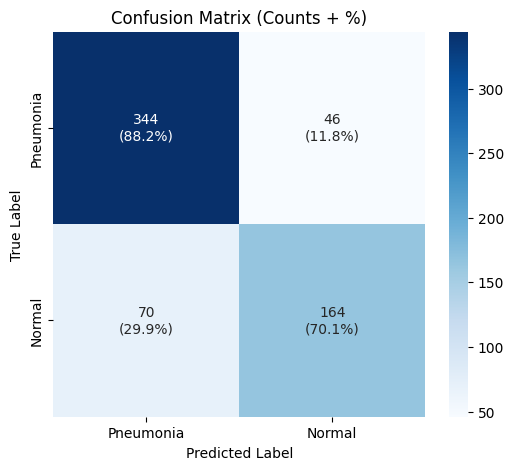

In [26]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]



import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

# Label
labels = ['Pneumonia', 'Normal']

#percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100


annot = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)"


# Plottin confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Counts + %)")
plt.show()

#Some correctly Predicted Classes---->>>

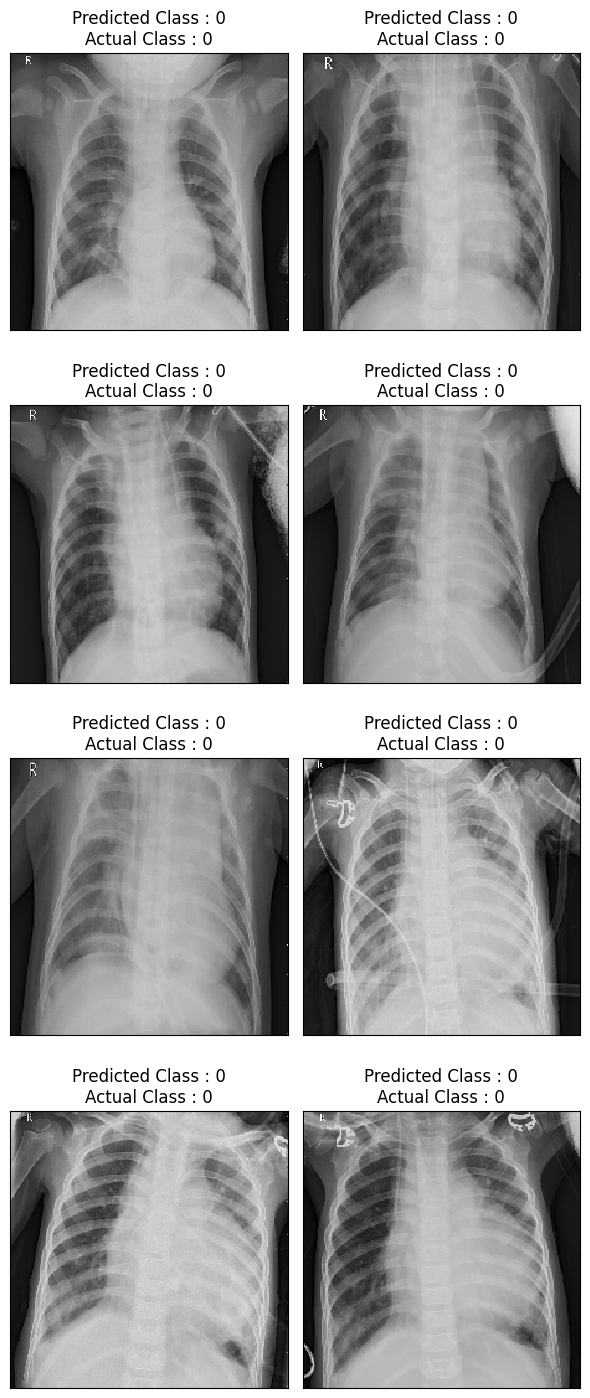

In [27]:
i = 0
plt.figure(figsize=(6,15))
for c in correct[10:18]:
    plt.subplot(4,2,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[c][:,:,0], cmap='gray', interpolation='none')
    plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
    plt.tight_layout()
    i += 1

#Some incorrectly Predicted Classes____>>>

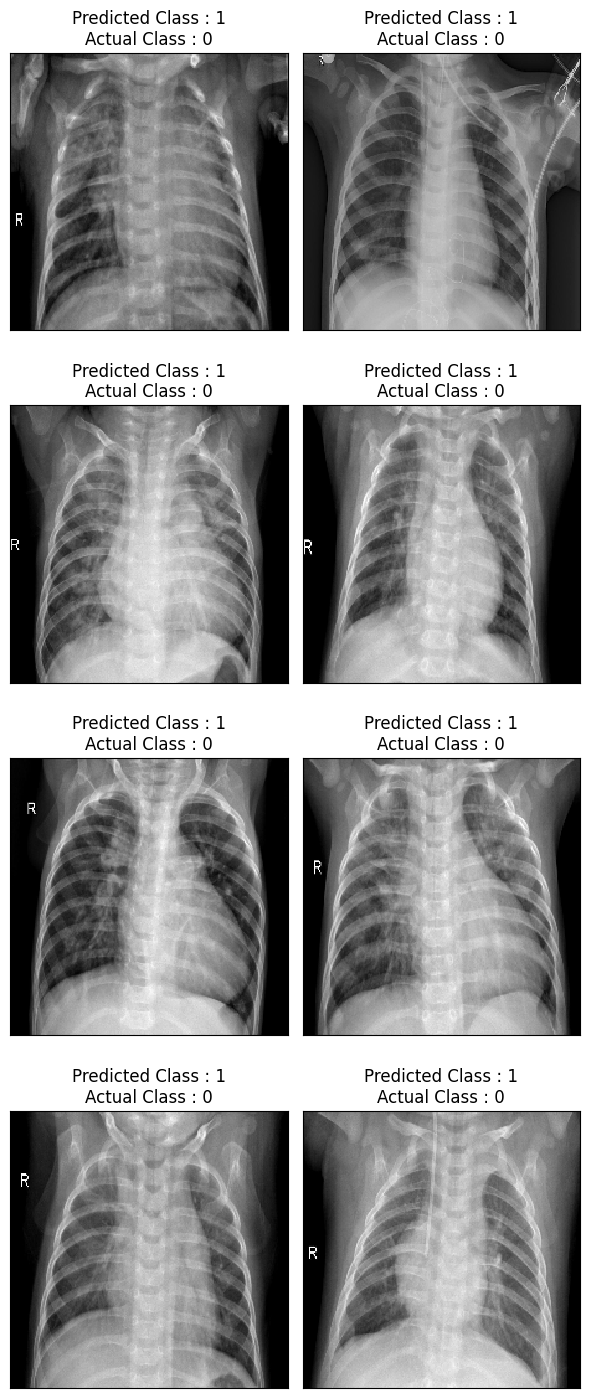

In [28]:
# //for incorrect predicted classes hum normal ko Penumonia dekha
# sakte hai but not vice versa........
i = 0
plt.figure(figsize=(6,15))
for c in incorrect[10:18]:
    plt.subplot(4,2,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[c][:,:,0], cmap='gray', interpolation='none')
    plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
    plt.tight_layout()
    i += 1